# Predictive Analytics Using Historical Data

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.preprocessing import LabelEncoder

In [2]:
# Creating sample historical data

np.random.seed(42)

dates = pd.date_range(start='2020-01-01', periods=500)

sales = (
    np.random.randint(100, 500, 500)
    + np.arange(500) * 2
)

advertising = np.random.randint(10, 100, 500)

customers = np.random.randint(20, 200, 500)

data = pd.DataFrame({
    'Date': dates,
    'Advertising_Spend': advertising,
    'Customers': customers,
    'Sales': sales
})

data.head()

,Date,Advertising_Spend,Customers,Sales
0,2020-01-01,10,45,202
1,2020-01-02,25,198,450
2,2020-01-03,70,192,374
3,2020-01-04,73,63,212
4,2020-01-05,72,152,179


In [3]:
data.to_csv("historical_sales_data.csv", index=False)

In [4]:
df = pd.read_csv("historical_sales_data.csv")

df.head()

,Date,Advertising_Spend,Customers,Sales
0,2020-01-01,10,45,202
1,2020-01-02,25,198,450
2,2020-01-03,70,192,374
3,2020-01-04,73,63,212
4,2020-01-05,72,152,179


# Data Cleaning & Preprocessing

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               500 non-null    object
 1   Advertising_Spend  500 non-null    int64 
 2   Customers          500 non-null    int64 
 3   Sales              500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB
None


In [6]:
print(df.isnull().sum())

Date                 0
Advertising_Spend    0
Customers            0
Sales                0
dtype: int64


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

,Date,Advertising_Spend,Customers,Sales,Year,Month,Day
0,2020-01-01,10,45,202,2020,1,1
1,2020-01-02,25,198,450,2020,1,2
2,2020-01-03,70,192,374,2020,1,3
3,2020-01-04,73,63,212,2020,1,4
4,2020-01-05,72,152,179,2020,1,5


In [9]:
print(df.describe())

                      Date  Advertising_Spend   Customers        Sales  \
count                  500         500.000000  500.000000   500.000000   
mean   2020-09-06 12:00:00          53.900000  108.912000   802.018000   
min    2020-01-01 00:00:00          10.000000   20.000000   132.000000   
25%    2020-05-04 18:00:00          31.000000   61.000000   563.750000   
50%    2020-09-06 12:00:00          54.500000  108.000000   802.500000   
75%    2021-01-09 06:00:00          76.000000  156.000000  1052.750000   
max    2021-05-14 00:00:00          99.000000  199.000000  1470.000000   
std                    NaN          26.430724   52.577076   309.071221   

              Year       Month         Day  
count   500.000000  500.000000  500.000000  
mean   2020.268000    5.508000   15.470000  
min    2020.000000    1.000000    1.000000  
25%    2020.000000    3.000000    8.000000  
50%    2020.000000    5.000000   15.000000  
75%    2021.000000    8.000000   23.000000  
max    2021.000000

## Corelation Heatmap

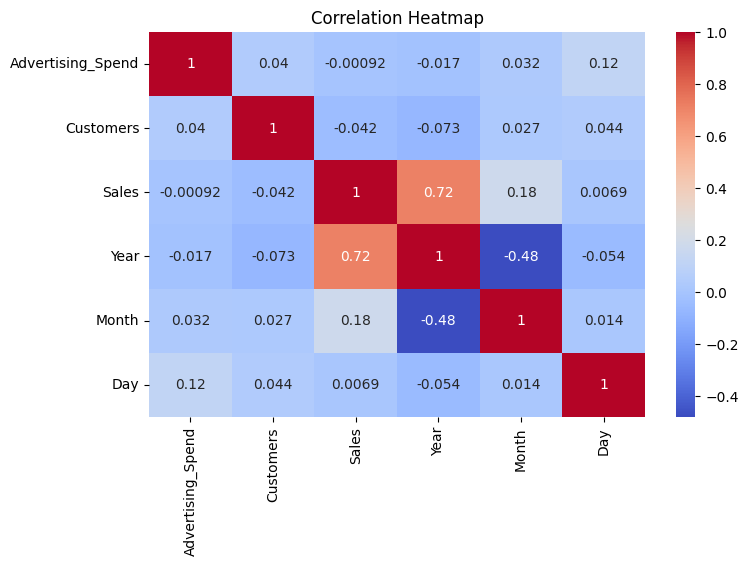

In [10]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

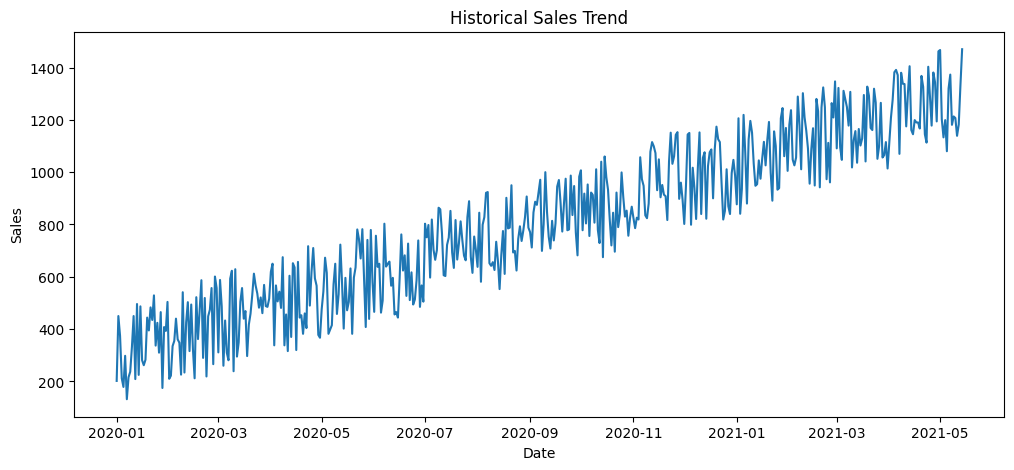

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Sales'])

plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [12]:
X = df[['Advertising_Spend', 'Customers', 'Year', 'Month', 'Day']]

y = df['Sales']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1023.48831247  448.30447071 1052.90791786  613.54683754  502.89131483
 1087.9707578  1057.29243748  558.14909583  433.29270032 1214.35095992]
